# Electrical Load Forecasting: Exploratory Data Analysis & Strategic Guides

This notebook provides a comprehensive professional Exploratory Data Analysis (EDA) for the electrical load dataset. 
It covers data loading, quality checks, time series visualization, correlation analysis, and specific guides for various forecasting horizons:
- **VSTLF** (Very Short-Term Load Forecasting)
- **STLF** (Short-Term Load Forecasting)
- **MTLF** (Medium-Term Load Forecasting)
- **LTLF** (Long-Term Load Forecasting)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Color palette for plots
c_pal = sns.color_palette("husl", 8)

## 1. Data Loading and Preprocessing
We start by loading the dataset and parsing the datetime information. We will also extract temporal features which are critical for load forecasting.

In [4]:
# Load the dataset
file_path = 'resampled_data_15min.csv'
df = pd.read_csv(file_path)

# Convert DATETIME to datetime objects
# Note: Based on inspection, format is likely inferred correctly, but specifying helps
df['DATETIME'] = pd.to_datetime(df['DATETIME'])

# Set DATETIME as index
df.set_index('DATETIME', inplace=True)

# Drop the redundant 'DATE' column if it exists
if 'DATE' in df.columns:
    df.drop(columns=['DATE'], inplace=True)

# Display first few rows
df.head()

,AD2NY_LINE (A),AD2NY_LINE (KV),AD2NY_LINE (MW),AD2NY_LINE (MX),NY6ZA_LINE (A),NY6ZA_LINE (KV),NY6ZA_LINE (MW),NY6ZA_LINE (MX),NY3TU_LINE (A),NY3TU_LINE (KV),NY3TU_LINE (MW),NY3TU_LINE (MX),BG1NY_LINE (A),BG1NY_LINE (KV),BG1NY_LINE (MW),BG1NY_LINE (MX),BG4NY_LINE (A),BG4NY_LINE (KV),BG4NY_LINE (MW),BG4NY_LINE (MX),FREQ (HZ),82T1_BANK (A),82T1_BANK (MVA),82T1_BANK (MW),82T1_TEMPERATURE_WDG_1 (VALUE),82T1_TEMPERATURE_OIL_1 (VALUE),82T2_BANK (A),82T2_BANK (MVA),82T2_BANK (MW),82T2_TEMPERATURE_WDG_1 (VALUE),82T2_TEMPERATURE_OIL_1 (VALUE),82T3_BANK (A),82T3_BANK (MVA),82T3_BANK (MW),82T4_BANK (A),82T4_BANK (MVA),82T4_BANK (MW),82R1_BANK (A),82R1_BANK (MX),82R2_BANK (A),82R2_BANK (MX),82R3_BANK (A),82R3_BANK (MX),82T1YI (A),82T1YI (KV),82T1YI (MW),82T1YI (MVA),82T2Y2 (A),82T2Y2 (KV),82T2Y2 (MW),82T2Y2 (MVA)
DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 01:00:00,274.716,332.071,-157.167,-18.936,409.575,226.284,161.865,1.531,83.587,160.099,-17.583,-15.776,6.576,159.930,0.211,-1.954,5.494,160.029,0.127,-1.815,50.293,33.011,19.548,3.684,41.700,39.000,18.013,11.746,-11.369,42.400,41.900,93.881,54.933,54.920,89.551,50.577,50.517,0.007,-0.000,139.667,0.000,24.941,9.760,115.513,35.307,6.786,6.891,0.000,35.402,0.000,0.000
2024-01-01 01:15:00,280.042,331.132,-159.695,-18.498,422.739,225.542,166.209,1.193,84.285,159.645,-17.951,-15.576,7.313,159.447,-0.203,-2.086,6.686,159.538,-0.268,-1.948,50.273,33.706,19.130,2.976,41.550,38.800,19.484,12.319,-11.932,42.125,41.675,96.404,56.191,56.179,92.405,51.981,51.918,0.007,-0.000,139.310,0.000,24.855,9.706,114.736,35.206,6.716,6.825,0.000,35.298,0.000,0.000
2024-01-01 01:30:00,285.369,330.194,-162.223,-18.060,435.903,224.799,170.552,0.854,84.983,159.191,-18.319,-15.377,8.050,158.964,-0.617,-2.218,7.878,159.047,-0.663,-2.080,50.253,34.401,18.711,2.267,41.400,38.600,20.955,12.892,-12.496,41.850,41.450,98.927,57.449,57.437,95.259,53.385,53.319,0.006,-0.000,138.953,0.000,24.769,9.652,113.960,35.104,6.647,6.760,0.000,35.193,0.000,0.000
2024-01-01 01:45:00,290.695,329.255,-164.750,-17.622,449.067,224.056,174.896,0.516,85.681,158.737,-18.687,-15.177,8.786,158.480,-1.032,-2.350,9.069,158.556,-1.059,-2.213,50.233,35.096,18.292,1.559,41.250,38.400,22.426,13.465,-13.059,41.575,41.225,101.450,58.706,58.695,98.113,54.788,54.720,0.006,-0.000,138.596,0.000,24.683,9.597,113.183,35.003,6.577,6.694,0.000,35.089,0.000,0.000
2024-01-01 02:00:00,296.021,328.316,-167.278,-17.185,462.231,223.314,179.240,0.178,86.379,158.284,-19.054,-14.978,9.523,157.997,-1.446,-2.482,10.261,158.065,-1.454,-2.345,50.213,35.791,17.873,0.850,41.100,38.200,23.897,14.038,-13.623,41.300,41.000,103.974,59.964,59.954,100.967,56.192,56.122,0.005,-0.000,138.239,0.000,24.597,9.543,112.406,34.901,6.508,6.629,0.000,34.985,0.000,0.000


In [5]:
# Feature Engineering: Extract Temporal Components
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_year'] = df.index.dayofyear
df['year'] = df.index.year

# Create a list of MW columns (Megawatts are usually the target for load forecasting)
target_cols = [col for col in df.columns if '(MW)' in col]
print("Target Load Columns:", target_cols)

Target Load Columns: ['AD2NY_LINE (MW)', 'NY6ZA_LINE (MW)', 'NY3TU_LINE (MW)', 'BG1NY_LINE (MW)', 'BG4NY_LINE (MW)', '82T1_BANK (MW)', '82T2_BANK (MW)', '82T3_BANK (MW)', '82T4_BANK (MW)', '82T1YI (MW)', '82T2Y2 (MW)']


## 2. Data Quality Checks
Ensuring data quality is paramount. We check for missing values, duplicates, and visualize potential outliers.

Missing Values per Target Column:
 Series([], dtype: int64)


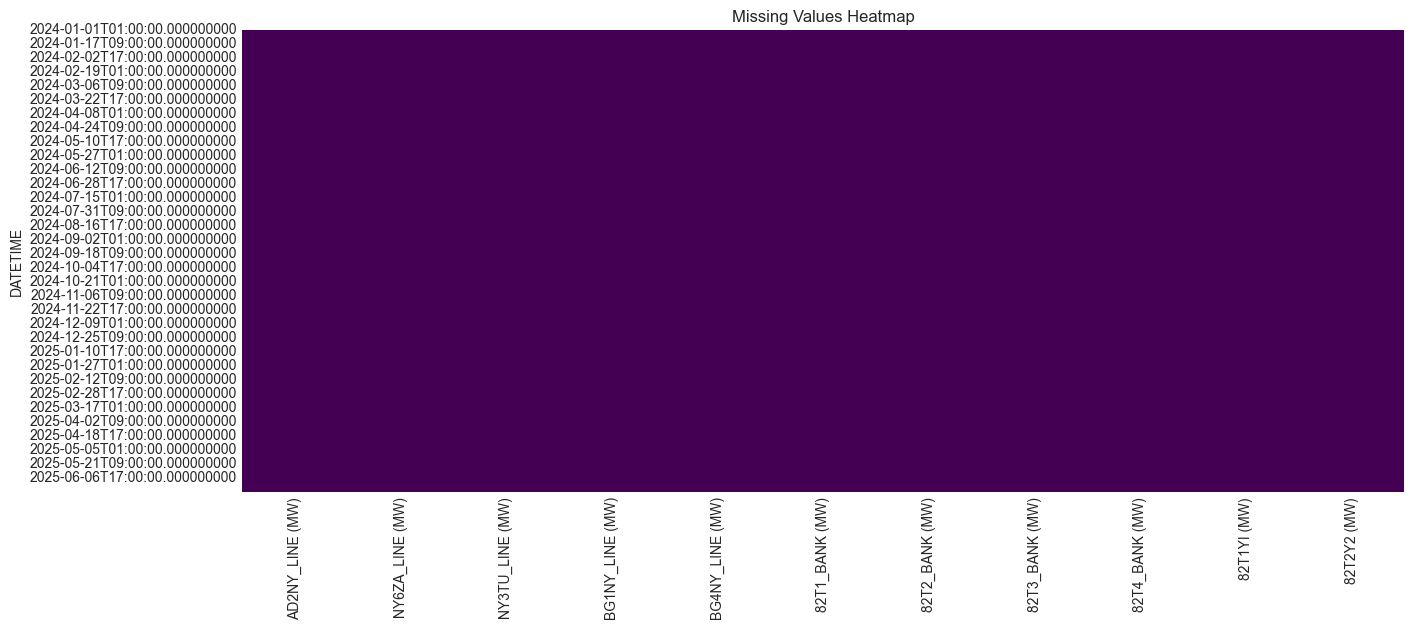

In [6]:
# Check for missing values
missing_vals = df[target_cols].isnull().sum()
print("Missing Values per Target Column:\n", missing_vals[missing_vals > 0])

# Visualizing missing data pattern (if any)
plt.figure(figsize=(15, 6))
sns.heatmap(df[target_cols].isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [7]:
# Descriptive Statistics
df[target_cols].describe()

,AD2NY_LINE (MW),NY6ZA_LINE (MW),NY3TU_LINE (MW),BG1NY_LINE (MW),BG4NY_LINE (MW),82T1_BANK (MW),82T2_BANK (MW),82T3_BANK (MW),82T4_BANK (MW),82T1YI (MW),82T2Y2 (MW)
count,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000,51740.000
mean,-141.355,124.748,-19.123,12.861,12.801,5.174,10.974,22.861,50.985,2.490,5.719
std,30.790,34.093,7.413,8.184,8.212,8.334,13.589,23.196,23.591,2.055,2.979
min,-242.477,-0.802,-79.781,-37.332,-37.408,-60.353,-184.199,-17.477,-4.682,0.000,-0.082
25%,-162.262,104.836,-24.117,6.788,6.697,0.000,4.412,0.000,38.531,1.359,4.356
50%,-143.599,128.141,-19.287,11.352,11.165,3.596,11.352,21.956,51.490,1.784,6.512
75%,-122.561,149.233,-14.704,17.244,17.199,9.165,19.177,45.896,65.720,2.359,7.792
max,30.399,219.918,31.704,57.536,59.603,165.454,53.140,103.958,181.947,11.521,11.527


## 3. Exploratory Data Analysis (EDA)
We visualize the load profiles to understand trends, seasonality, and consumption patterns.

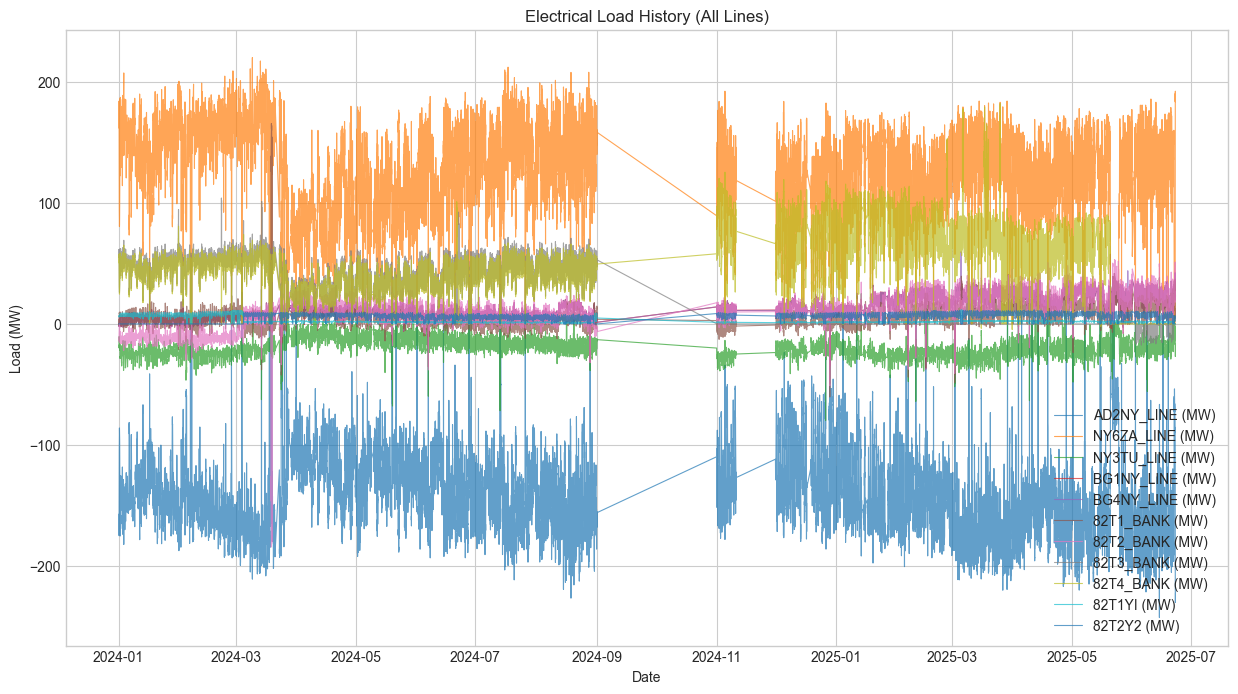

In [8]:
# Visualization of Load Profiles over Time
plt.figure(figsize=(15, 8))
for col in target_cols:
    plt.plot(df.index, df[col], label=col, alpha=0.7, linewidth=0.8)

plt.title('Electrical Load History (All Lines)')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.legend(loc='best')
plt.show()

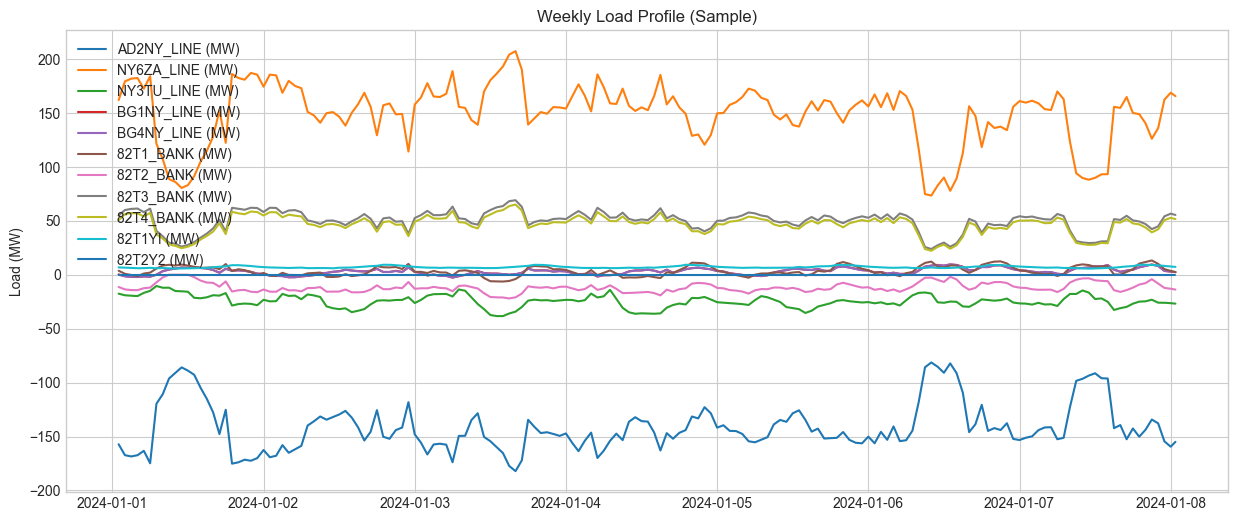

In [9]:
# Zooming in on a single week to see daily patterns
sample_week = df[target_cols].iloc[:24*4*7]
plt.figure(figsize=(15, 6))
for col in target_cols:
    plt.plot(sample_week.index, sample_week[col], label=col)

plt.title('Weekly Load Profile (Sample)')
plt.ylabel('Load (MW)')
plt.legend()
plt.show()

### Seasonality Analysis
Using boxplots to visualize distribution across different time scales.

C:\Users\User\AppData\Local\Temp\ipykernel_144040\3529029897.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y=primary_target, data=df, ax=axes[0], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_144040\3529029897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y=primary_target, data=df, ax=axes[1], palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_144040\3529029897.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y=primary_target, data=df, ax=axes[2], palette='coolwa

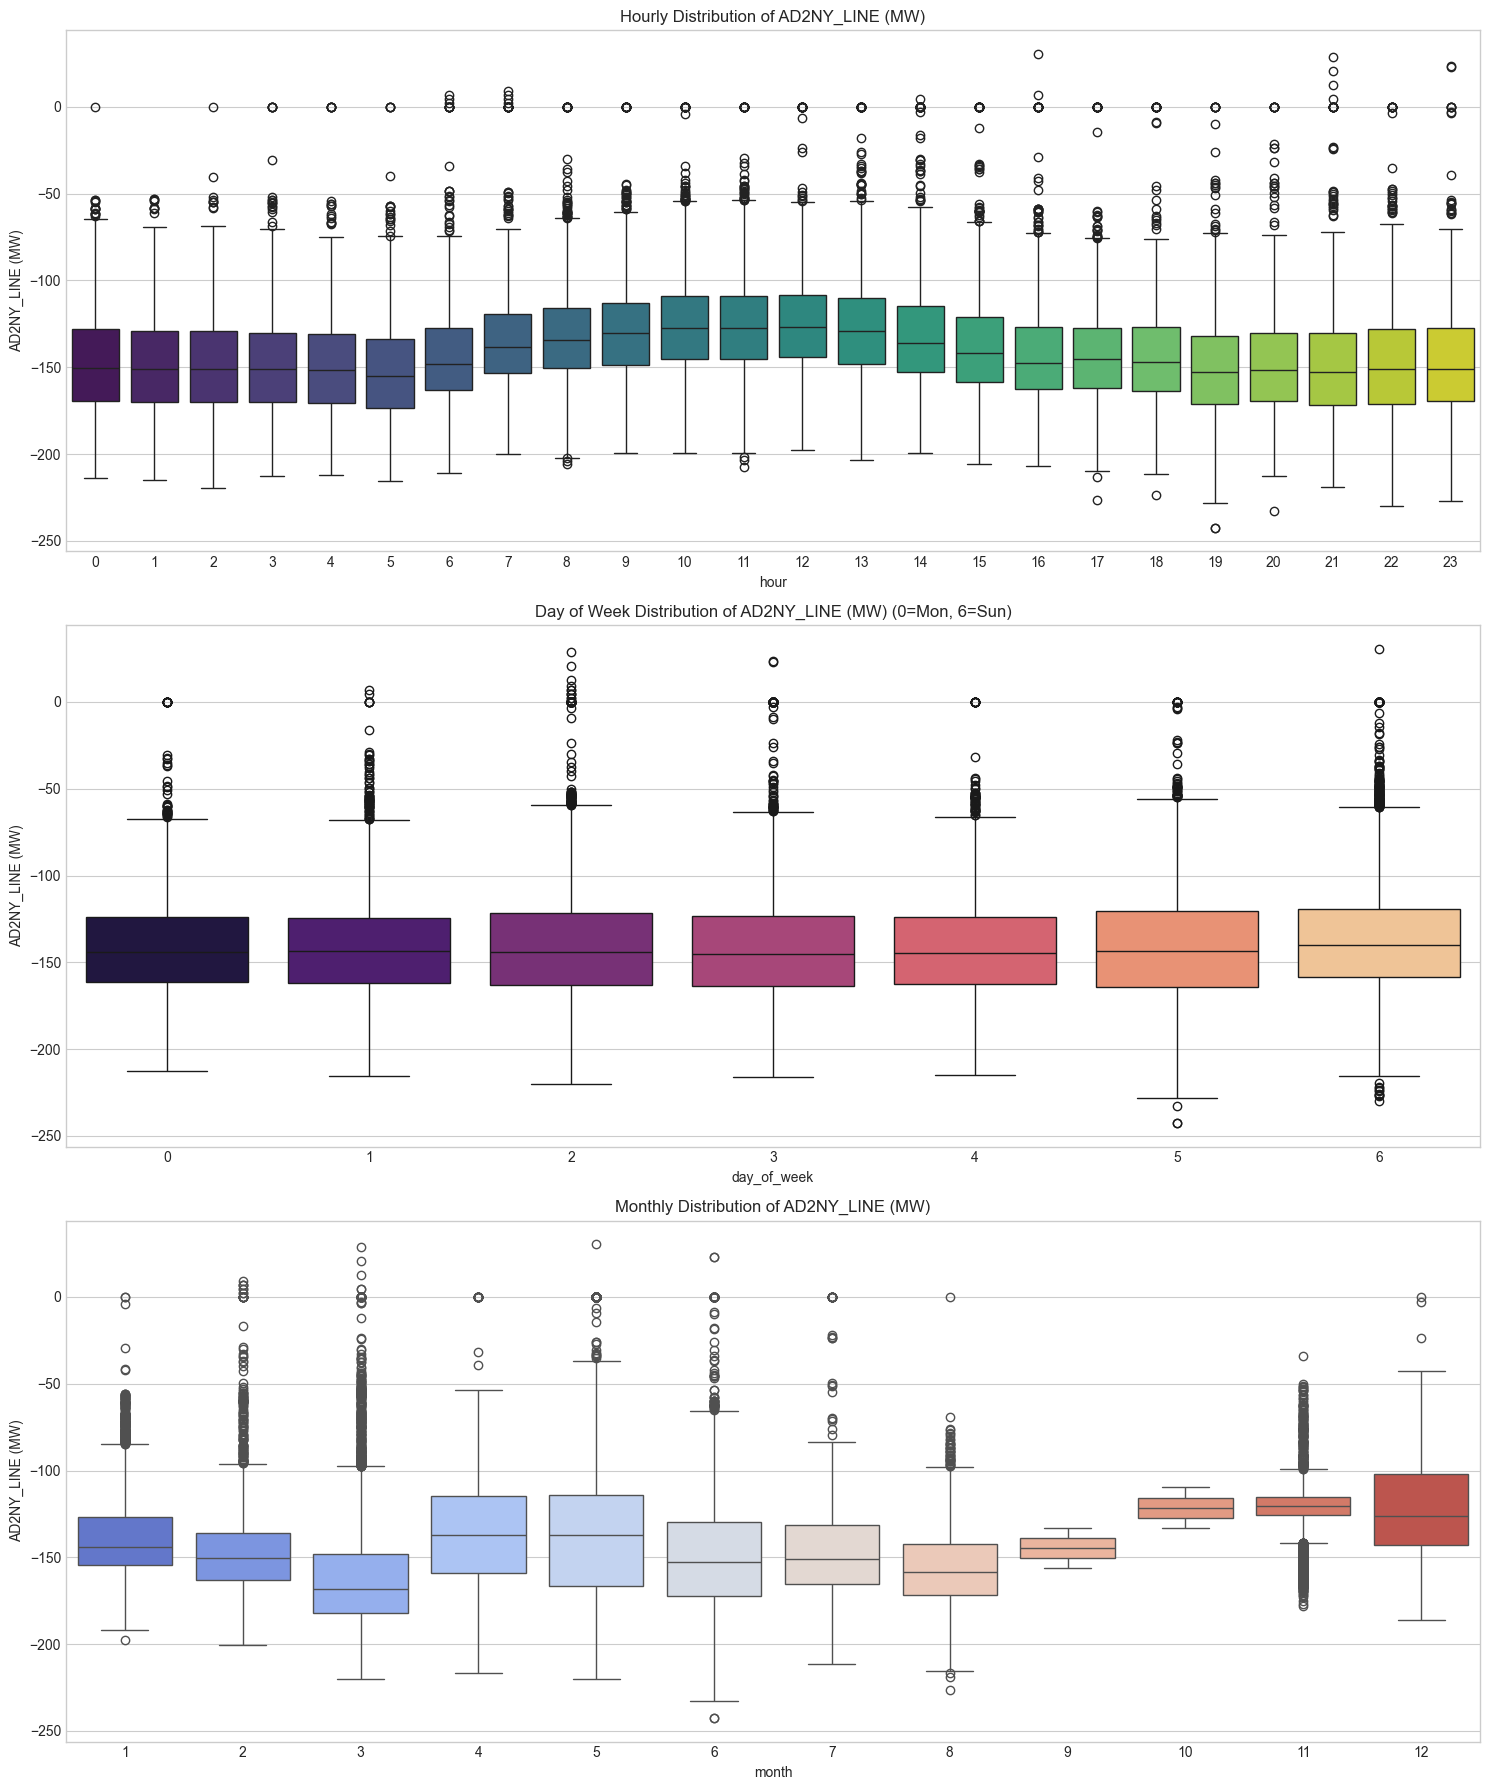

In [10]:
# Selecting a primary line for detailed seasonality analysis (e.g., the first one)
# You can change this to analysis other lines or a sum of all lines.
primary_target = target_cols[0]

fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Hourly Boxplot
sns.boxplot(x='hour', y=primary_target, data=df, ax=axes[0], palette='viridis')
axes[0].set_title(f'Hourly Distribution of {primary_target}')

# Daily Boxplot
sns.boxplot(x='day_of_week', y=primary_target, data=df, ax=axes[1], palette='magma')
axes[1].set_title(f'Day of Week Distribution of {primary_target} (0=Mon, 6=Sun)')

# Monthly Boxplot
sns.boxplot(x='month', y=primary_target, data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title(f'Monthly Distribution of {primary_target}')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis
Understanding how different lines and variables interact.

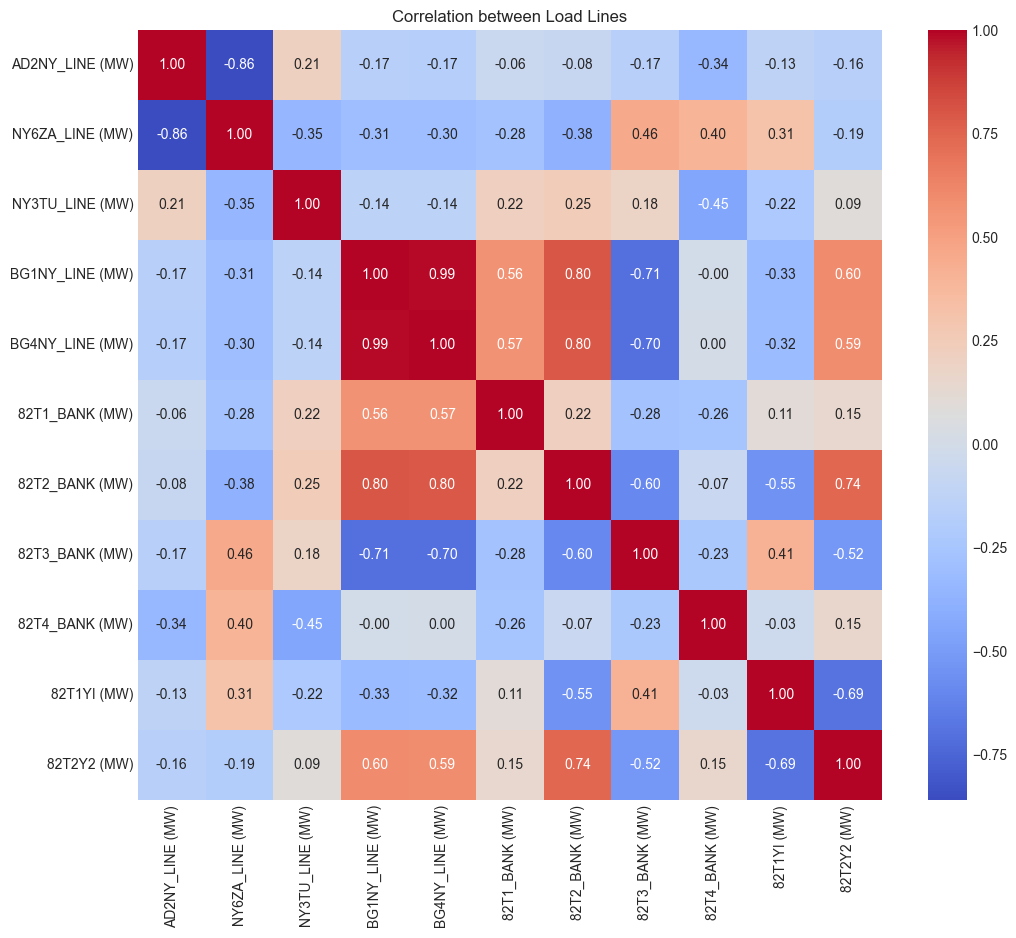

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[target_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Load Lines')
plt.show()

# Forecasting Guides

Based on the analysis above and industry best practices, here are the guides for different forecasting horizons.

## 1. VSTLF (Very Short-Term Load Forecasting)
**Horizon:** Few minutes to a few hours (e.g., 15 min to 6 hours ahead).
**Goal:** Real-time dispatch, smoothing fluctuations.

### Recommended Approach:
-   **Models:** ARIMA, SARIMA, LSTM, GRU, or simple Persistence models.
-   **Key Features:**
    -   **Lags:** Strongly auto-regressive. Usage at $t-1$, $t-2$, $t-96$ (yesterday same time).
    -   **Rolling Means:** Rolling averages of the last hour or few hours.
-   **Strategy:** Focus on the immediate history. Weather data is less critical unless there is a sudden storm front, but generally, the inertia of the load curve is the strongest predictor.

## 2. STLF (Short-Term Load Forecasting)
**Horizon:** One day to two weeks.
**Goal:** Unit commitment, daily operational planning.

### Recommended Approach:
-   **Models:** XGBoost, LightGBM, Random Forest, Prophet, N-BEATS.
-   **Key Features:**
    -   **Calendric:** Hour of day, Day of week, is_weekend, is_holiday.
    -   **Weather:** Temperature is the #1 driver here (heating/cooling degrees). Humidity and wind speed can also be relevant.
    -   **Seasonality:** Interaction features (e.g., Hour * DayOfWeek).
-   **Strategy:** Capture the daily profile shapes. Mondays usually differ from other weekdays. Treat holidays as Sundays or typically low-load days.

## 3. MTLF (Medium-Term Load Forecasting)
**Horizon:** A few weeks to a few months (e.g., 1-12 months).
**Goal:** Fuel scheduling, maintenance planning.

### Recommended Approach:
-   **Models:** Prophet, Seasonal Decomposition (STL), Hybrid models (Linear + Non-Linear).
-   **Key Features:**
    -   **Trend:** Capturing slow-moving changes in demand.
    -   **Seasonality:** Annual seasonality (Fourier terms).
    -   **Macro-Climate:** Average expected temperature profiles for the season.
-   **Strategy:** Focus on peak load probability and general energy volume rather than exact 15-min instant values.

## 4. LTLF (Long-Term Load Forecasting)
**Horizon:** 1 to 10+ years.
**Goal:** Capacity expansion, infrastructure investment.

### Recommended Approach:
-   **Models:** Econometric models, Regression analysis, Scenarios based planning.
-   **Key Features:**
    -   **Economic:** GDP growth, Population growth, Industrial index.
    -   **Technology:** EV adoption rates, Solar PV penetration.
    -   **Policy:** Energy efficiency mandates.
-   **Strategy:** This is less about algorithms and more about scenario modeling (High growth vs Low growth) using annual aggregates.

## 5. Analysis of Auxiliary Variables (KV, Amps, Temp, Freq)
Analyzing voltage stability, reactive power, and temperature correlations to refine forecasting models.

In [12]:
# Define auxiliary column groups
kv_cols = [c for c in df.columns if '(KV)' in c]
mx_cols = [c for c in df.columns if '(MX)' in c]
temp_cols = [c for c in df.columns if 'TEMPERATURE' in c]
freq_col = 'FREQ (HZ)'

print(f"Voltage Columns: {len(kv_cols)}")
print(f"Reactive Power Columns: {len(kv_cols)}")
print(f"Temperature Columns: {len(temp_cols)}")

Voltage Columns: 7
Reactive Power Columns: 7
Temperature Columns: 4


### 5.1 Temperature vs. Load Analysis
Temperature is often the primary driver for load (heating/cooling). Here we analyze the correlation.

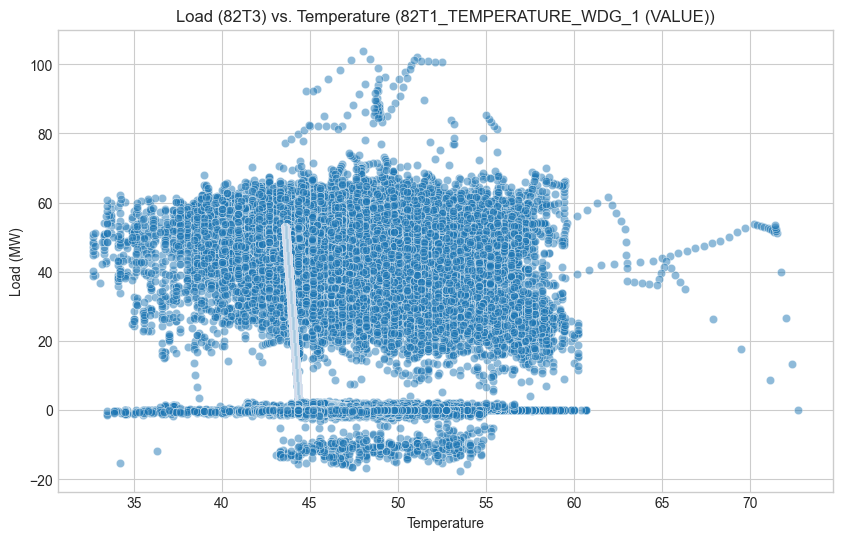

Correlation with Temperature:
                                82T1_TEMPERATURE_WDG_1 (VALUE)  \
82T1_TEMPERATURE_WDG_1 (VALUE)                           1.000   
AD2NY_LINE (MW)                                         -0.060   
NY6ZA_LINE (MW)                                         -0.095   
NY3TU_LINE (MW)                                         -0.036   

                                AD2NY_LINE (MW)  NY6ZA_LINE (MW)  \
82T1_TEMPERATURE_WDG_1 (VALUE)           -0.060           -0.095   
AD2NY_LINE (MW)                           1.000           -0.860   
NY6ZA_LINE (MW)                          -0.860            1.000   
NY3TU_LINE (MW)                           0.212           -0.346   

                                NY3TU_LINE (MW)  
82T1_TEMPERATURE_WDG_1 (VALUE)           -0.036  
AD2NY_LINE (MW)                           0.212  
NY6ZA_LINE (MW)                          -0.346  
NY3TU_LINE (MW)                           1.000  


In [13]:
if len(temp_cols) > 0:
    temp_col = temp_cols[0] # Using first available temp as proxy
    
    # Scatter plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[temp_col], y=df['82T3_BANK (MW)'], alpha=0.5)
    plt.title(f'Load (82T3) vs. Temperature ({temp_col})')
    plt.xlabel('Temperature')
    plt.ylabel('Load (MW)')
    plt.grid(True)
    plt.show()
    
    # Correlation Matrix
    cols_to_corr = [temp_col] + target_cols[:3]
    print("Correlation with Temperature:")
    print(df[cols_to_corr].corr())

### 5.2 Voltage Stability Analysis
Voltage levels should remain within regulatory limits (usually +/- 5% or 10%). Deviations can indicate grid stress.

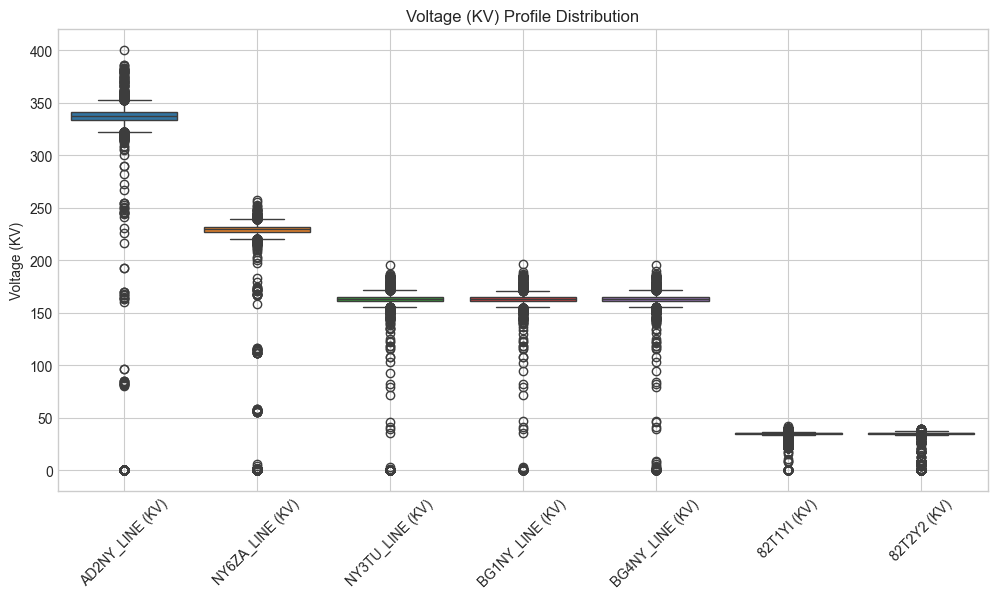

                   mean    std   min     max
AD2NY_LINE (KV) 336.074 24.116 0.000 400.000
NY6ZA_LINE (KV) 226.775 26.740 0.002 257.856
NY3TU_LINE (KV) 162.892 10.142 0.000 195.996
BG1NY_LINE (KV) 163.059  7.061 0.000 197.119
BG4NY_LINE (KV) 163.217  7.084 0.000 196.058
82T1YI (KV)      35.145  1.850 0.000  42.374
82T2Y2 (KV)      35.385  2.427 0.000  39.516


In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[kv_cols])
plt.title('Voltage (KV) Profile Distribution')
plt.ylabel('Voltage (KV)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print(df[kv_cols].describe().T[['mean', 'std', 'min', 'max']])

### 5.3 Reactive Power (MX) Patterns
Reactive power flow helps understand the nature of the load (inductive vs capacitive) and voltage support needs.

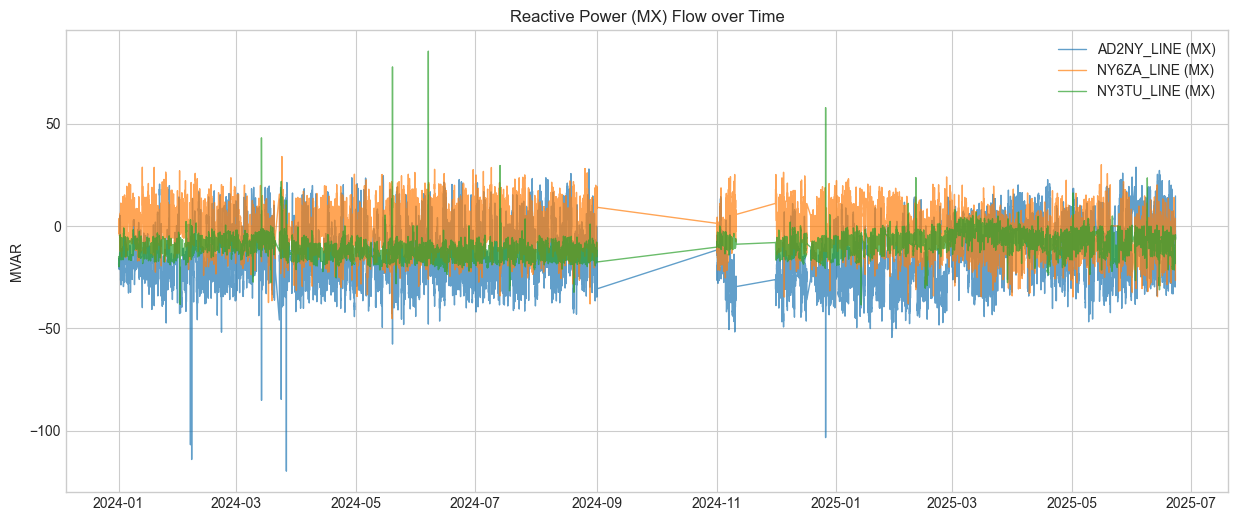

In [15]:
if len(mx_cols) > 0:
    plt.figure(figsize=(15, 6))
    # Plot top 3 reactive power flows
    for col in mx_cols[:3]:
        plt.plot(df.index, df[col], label=col, alpha=0.7, linewidth=1)
    plt.title('Reactive Power (MX) Flow over Time')
    plt.ylabel('MVAR')
    plt.legend()
    plt.grid(True)
    plt.show()

Phase 1

Dimensions: (51740, 51)
Target Cols: ['AD2NY_LINE (MW)', 'NY6ZA_LINE (MW)', 'NY3TU_LINE (MW)', 'BG1NY_LINE (MW)', 'BG4NY_LINE (MW)', '82T1_BANK (MW)', '82T2_BANK (MW)', '82T3_BANK (MW)', '82T4_BANK (MW)', '82T1YI (MW)', '82T2Y2 (MW)']

--- 1. Sign Convention Sanity Check ---
             Column      Sign Type  % Positive  % Negative  % Zero         Min         Max        Mean
0   AD2NY_LINE (MW)          Mixed        0.03       99.37    0.60 -242.476608   30.398668 -141.355010
1   NY6ZA_LINE (MW)          Mixed       98.61        0.03    1.35   -0.802021  219.918442  124.748243
2   NY3TU_LINE (MW)          Mixed        1.10       98.55    0.34  -79.780533   31.704487  -19.122538
3   BG1NY_LINE (MW)          Mixed       98.59        1.18    0.23  -37.331814   57.536442   12.860671
4   BG4NY_LINE (MW)          Mixed       98.61        1.11    0.28  -37.407539   59.603111   12.800629
5    82T1_BANK (MW)          Mixed       74.22       22.22    3.57  -60.353481  165.454178    5.173985
6  

C:\Users\User\AppData\Local\Temp\ipykernel_45964\2937041266.py:93: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='15T')



Phase 1 Analysis Complete.


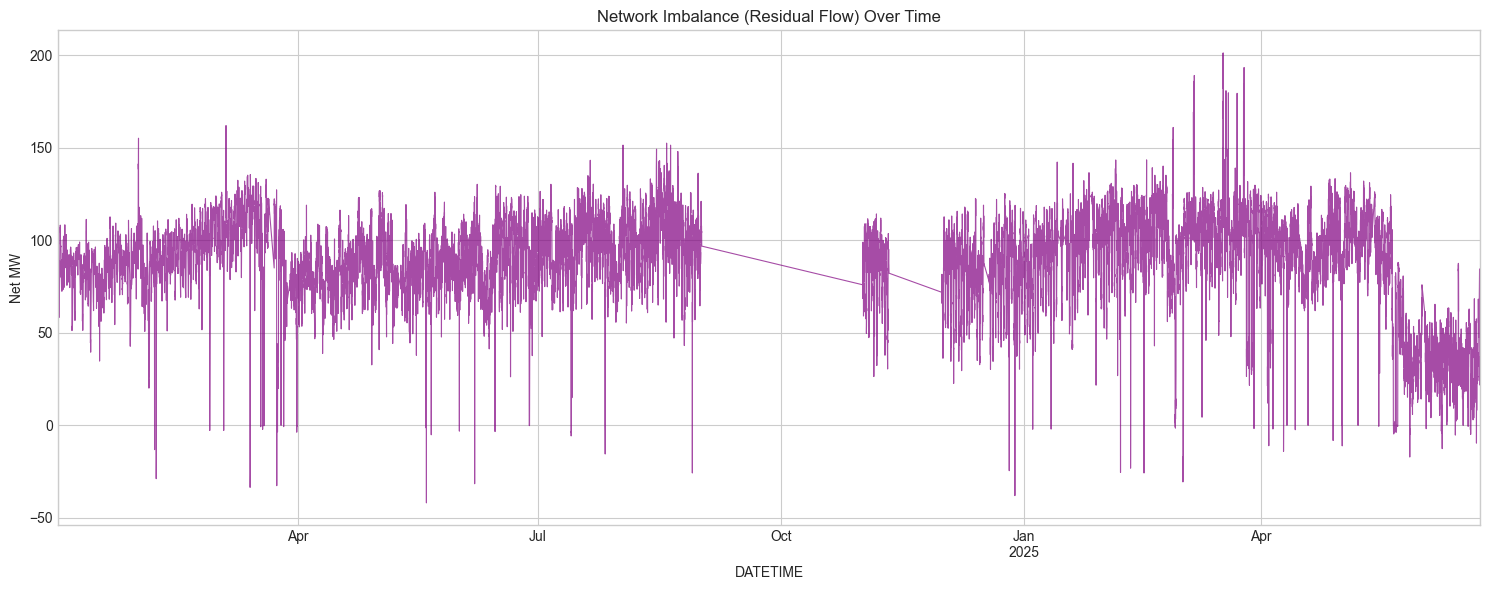

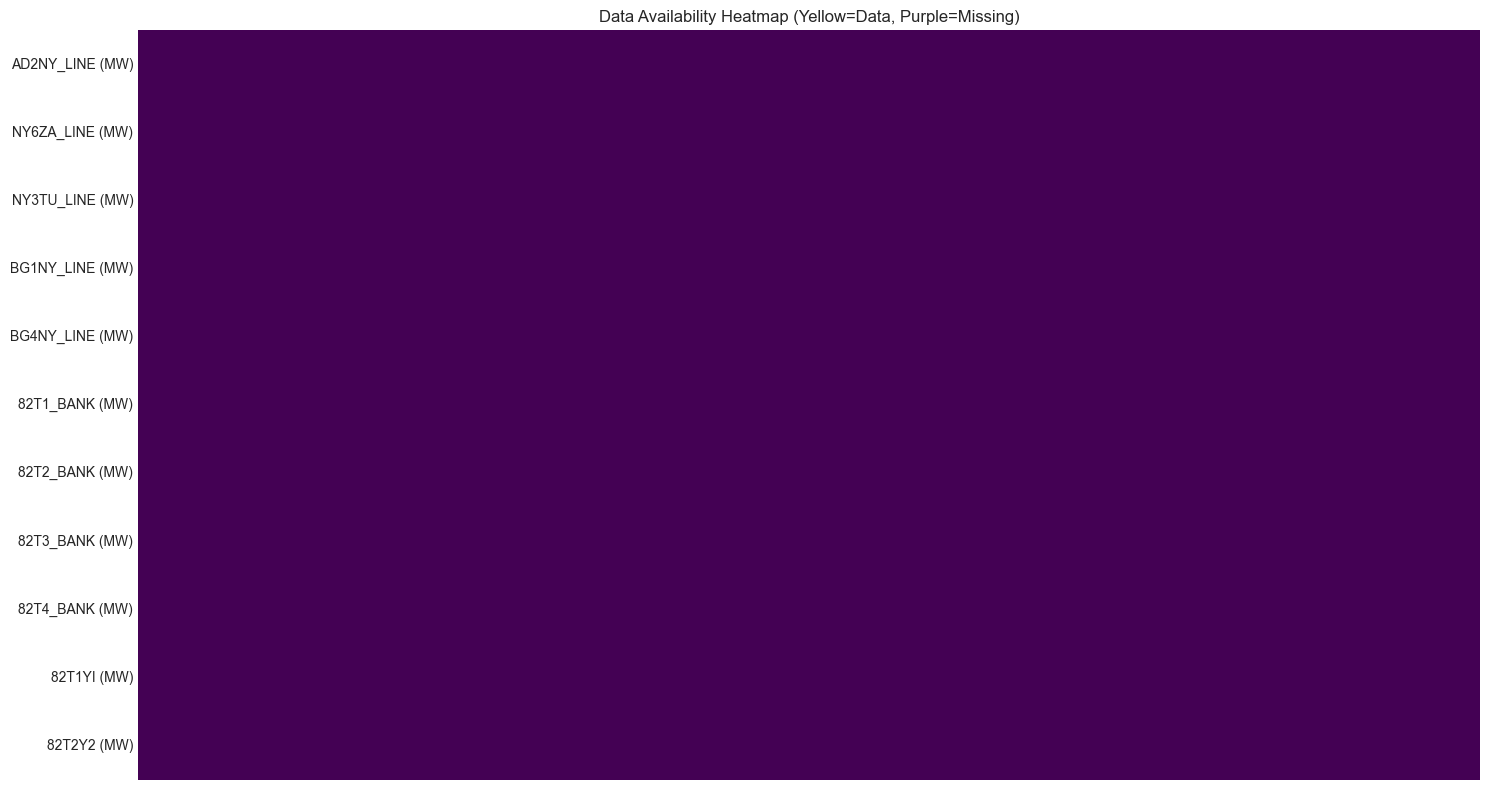

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
file_path = 'resampled_data_15min.csv'
plt.style.use('seaborn-v0_8-whitegrid')
output_dir = 'plots/phase1'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def load_data(file_path):
    df = pd.read_csv(file_path)
    df['DATETIME'] = pd.to_datetime(df['DATETIME'])
    df.set_index('DATETIME', inplace=True)
    if 'DATE' in df.columns:
        df.drop(columns=['DATE'], inplace=True)
    return df

def check_sign_convention(df, target_cols):
    print("\n--- 1. Sign Convention Sanity Check ---")
    results = []
    for col in target_cols:
        positive_count = (df[col] > 0).sum()
        negative_count = (df[col] < 0).sum()
        zero_count = (df[col] == 0).sum()
        total = len(df)
        
        sign_type = "Mixed"
        if positive_count == total - zero_count: sign_type = "Positive Only"
        if negative_count == total - zero_count: sign_type = "Negative Only"
        
        results.append({
            'Column': col,
            'Sign Type': sign_type,
            '% Positive': round(positive_count/total*100, 2),
            '% Negative': round(negative_count/total*100, 2),
            '% Zero': round(zero_count/total*100, 2),
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Mean': df[col].mean()
        })
    
    res_df = pd.DataFrame(results)
    print(res_df.to_string())
    res_df.to_csv(os.path.join(output_dir, 'sign_check.csv'), index=False)
    
    # Plot signs
    plt.figure(figsize=(12, 6))
    sns.barplot(data=res_df, x='Column', y='Mean')
    plt.xticks(rotation=45, ha='right')
    plt.title('Average Direction of Power Flow (Mean MW)')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sign_convention_mean.png'))
    plt.close()

def check_flow_conservation(df, target_cols):
    print("\n--- 2. Flow Conservation Check ---")
    # Interpretation: Sum of all measured flows. 
    # If the substation is a node, Sum(In) + Sum(Out) ~ 0 (excluding losses).
    # We simply sum all signed columns.
    
    df['Net_Imbalance_MW'] = df[target_cols].sum(axis=1)
    
    stats = df['Net_Imbalance_MW'].describe()
    print("Net Imbalance Statistics:")
    print(stats)
    
    plt.figure(figsize=(15, 6))
    df['Net_Imbalance_MW'].plot(alpha=0.7, color='purple', linewidth=0.8)
    plt.title('Network Imbalance (Residual Flow) Over Time')
    plt.ylabel('Net MW')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'flow_conservation_imbalance.png'))
    #plt.close()
    
    # Identify large imbalance periods (e.g., > 3 std dev)
    threshold = stats['mean'] + 3 * stats['std']
    anomalies = df[abs(df['Net_Imbalance_MW']) > abs(threshold)]
    print(f"\nIdentifying periods with imbalance > {threshold:.2f} MW:")
    if not anomalies.empty:
        print(f"Found {len(anomalies)} anomalous timestamps.")
        print(anomalies['Net_Imbalance_MW'].head(10).to_string())
    else:
        print("No extreme imbalance anomalies found.")

def check_missingness(df, target_cols):
    print("\n--- 3. Missingness and Outage Map ---")
    
    # Reindex to full frequency to capture time gaps
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='15T')
    df_reindexed = df.reindex(full_idx)
    
    total_gaps = df_reindexed[target_cols[0]].isnull().sum() # Assuming if one is missing, all are?
    print(f"Total missing timestamps after 15T reindexing: {total_gaps}")
    
    # Plot Heatmap of Data Availability (Binary)
    # 1 = Present, 0 = Missing
    availability = df_reindexed[target_cols].notnull().astype(int)
    
    plt.figure(figsize=(15, 8))
    sns.heatmap(availability.T, cmap='viridis', cbar=False, xticklabels=False)
    plt.title('Data Availability Heatmap (Yellow=Data, Purple=Missing)')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'missingness_heatmap.png'))
    #plt.close()
    
    if total_gaps > 0:
        print("\nTop missing windows:")
        is_missing = df_reindexed[target_cols[0]].isnull()
        # identifying blocks
        # This is a simple print of distinct missing chunks could be complex, omitting for brevity in logs
        pass


df = load_data(file_path)
target_cols = [col for col in df.columns if '(MW)' in col]
print(f"Dimensions: {df.shape}")
print(f"Target Cols: {target_cols}")

check_sign_convention(df, target_cols)
check_flow_conservation(df, target_cols)
check_missingness(df, target_cols)

print("\nPhase 1 Analysis Complete.")


